In [214]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, ConfusionMatrixDisplay)

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Model persistence
import joblib

print('All libraries imported successfully!')

All libraries imported successfully!


## LOAD DATASET <a id='4'></a>

In [215]:
df = pd.read_excel('C:\\Users\\Suresh\\projects\\customer-churn-prediction\\data\\Telco_customer_churn.xlsx')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head()

Dataset Shape: (7043, 33)

Columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## EDA (Exploratory Data Analysis) <a id='4'></a>

In [216]:
df.info()
df.describe()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

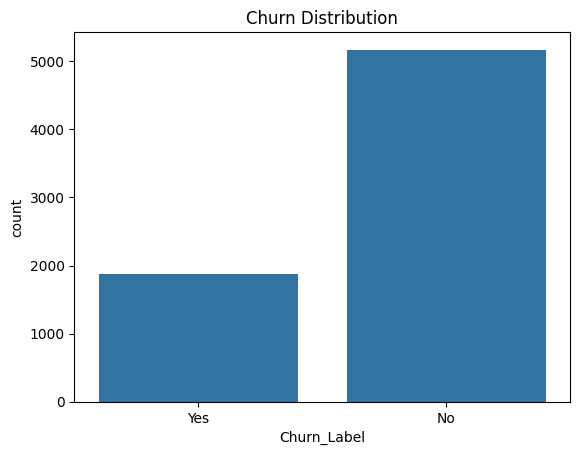

Churn_Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [217]:
df.columns = df.columns.str.replace(' ', '_')
churn_col = 'Churn_Label'

sns.countplot(x=churn_col, data=df)
plt.title("Churn Distribution")
plt.show()

print(df[churn_col].value_counts(normalize=True) * 100)

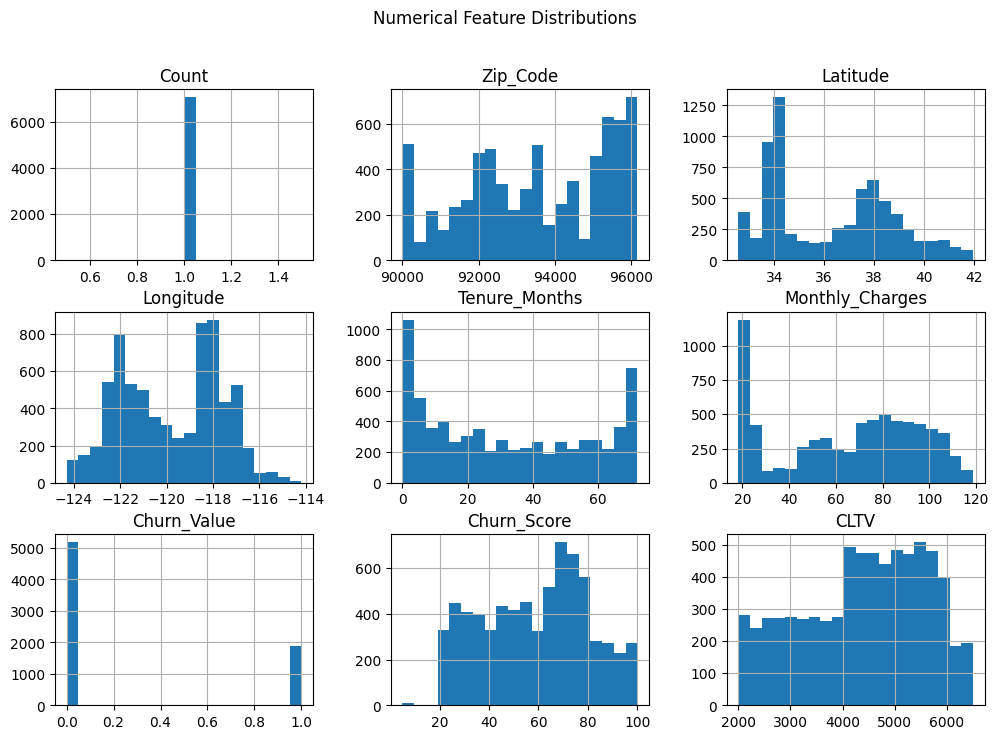

In [218]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

In [219]:
# Convert to numeric (handle empty strings)
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')
df = df.dropna(subset=['Total_Charges'])
print(df[['Total_Charges']].dtypes)

Total_Charges    float64
dtype: object


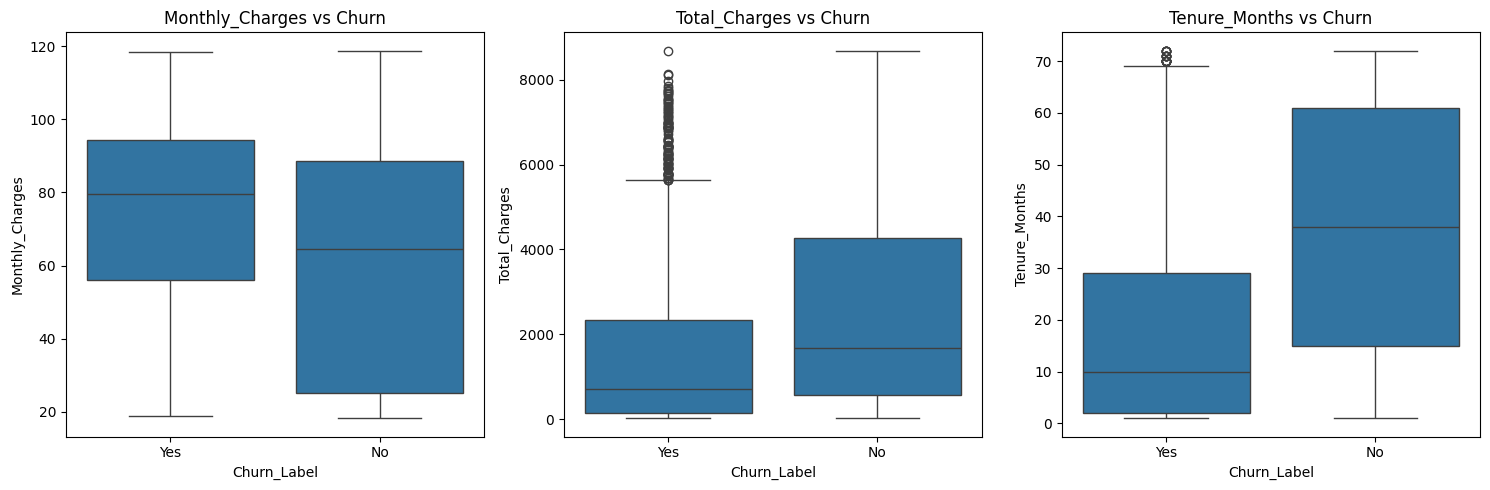

In [220]:
cols = ['Monthly_Charges', 'Total_Charges', 'Tenure_Months']

fig, axes = plt.subplots(1, len(cols), figsize=(15,5))

for i, col in enumerate(cols):
    if col in df.columns:
        sns.boxplot(x=churn_col, y=col, data=df, ax=axes[i])
        axes[i].set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

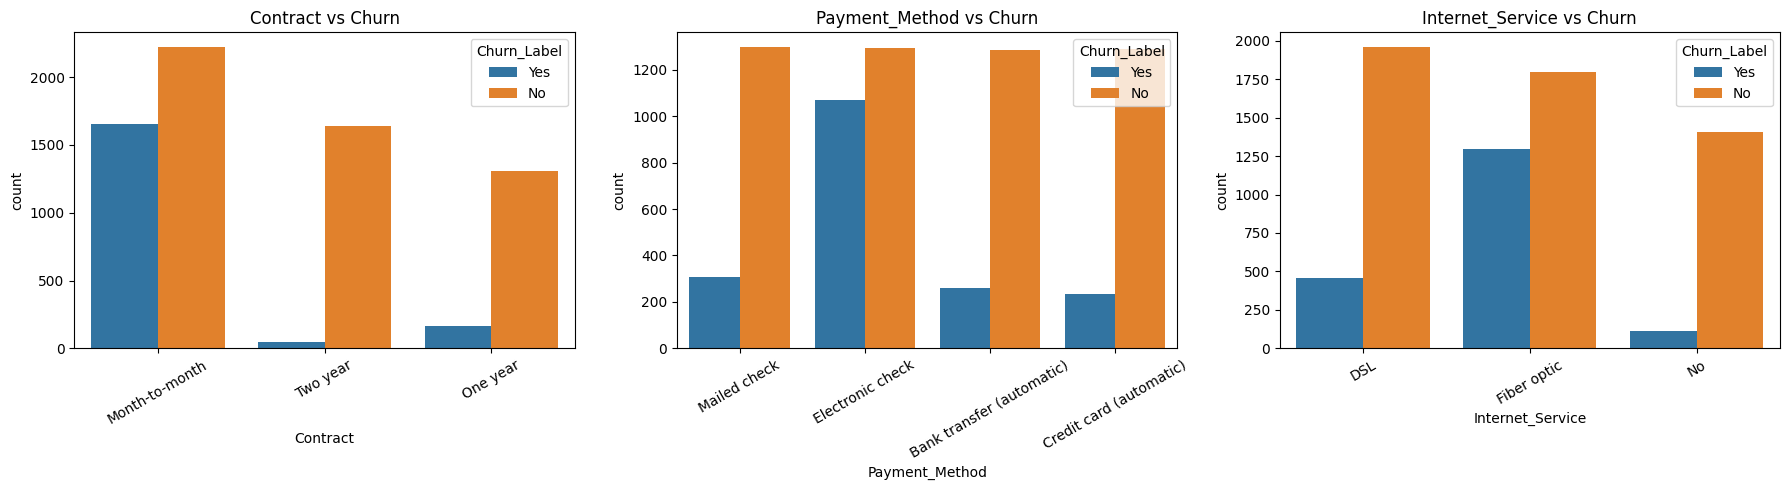

In [221]:
cat_cols = ['Contract', 'Payment_Method', 'Internet_Service']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18,5))

for i, col in enumerate(cat_cols):
    if col in df.columns:
        sns.countplot(x=col, hue=churn_col, data=df, ax=axes[i])
        axes[i].set_title(f"{col} vs Churn")
        axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

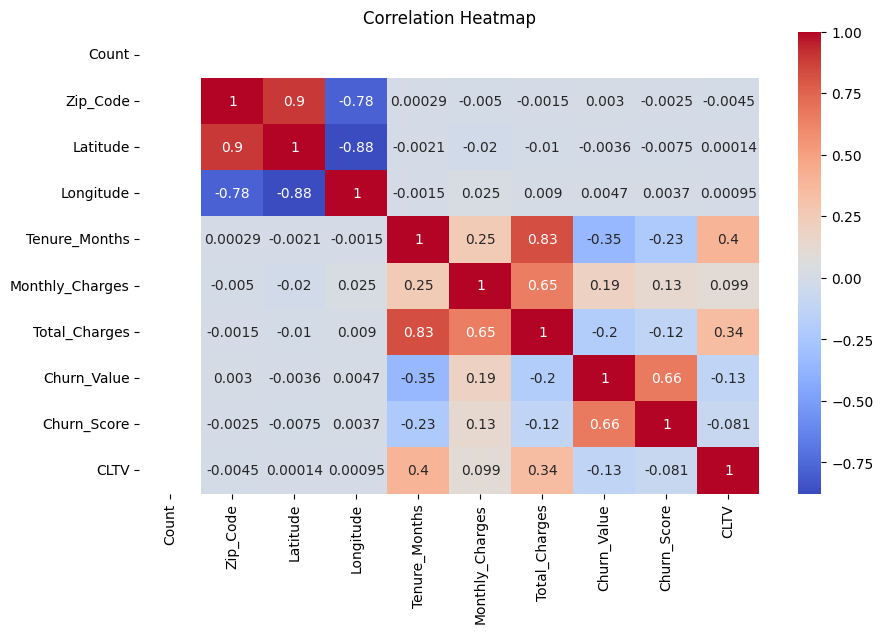

In [222]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

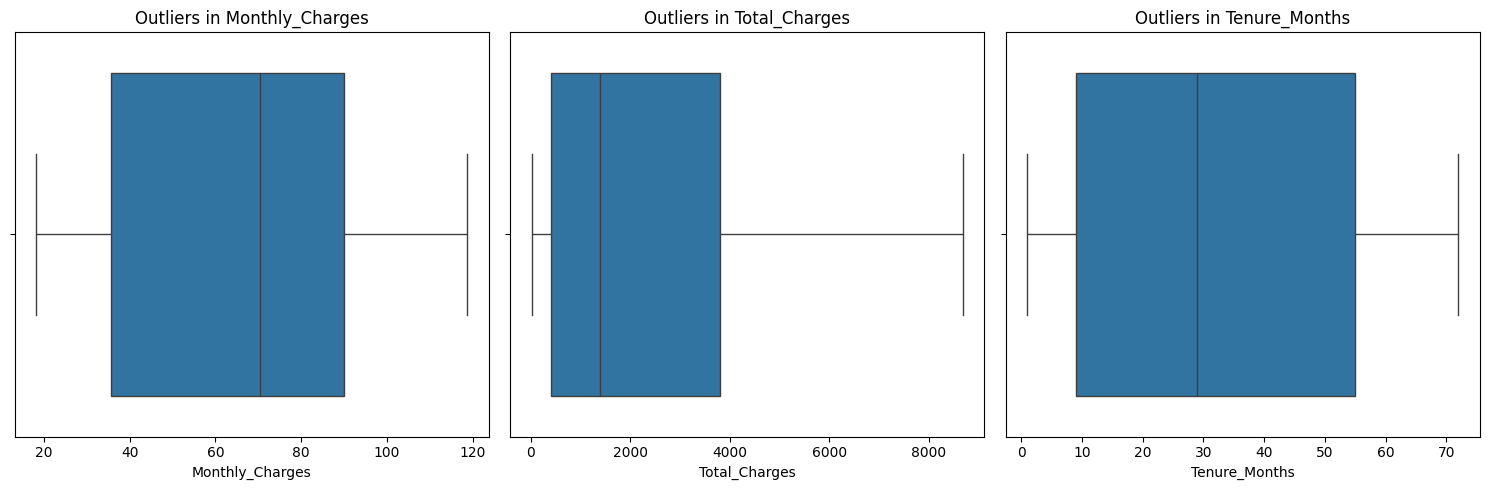

In [223]:
cols = ['Monthly_Charges', 'Total_Charges', 'Tenure_Months']

fig, axes = plt.subplots(1, len(cols), figsize=(15,5))

for i, col in enumerate(cols):
    if col in df.columns:
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f"Outliers in {col}")

plt.tight_layout()
plt.show()

Insights
- Dataset contains both numerical and categorical features.
- There is class imbalance in churn.
- Customers with higher monthly charges tend to churn more, Customers with lower tenure are more likely to leave.
- Customers with month-to-month contracts have higher churn rates, Payment method and internet service type also influence churn behavior.
- Total Charges and Tenure are highly correlated.
- Some extreme values exist in Monthly Charges and Total Charges.


## 4. Data Preprocessing & Cleaning <a id='4'></a>

In [224]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

DROP UNNECESSARY COLUMNS

In [225]:
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City',
    'Zip_Code', 'Lat_Long', 'Latitude', 'Longitude',
    'Churn_Score', 'CLTV', 'Churn_Reason'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

FIX TARGET COLUMN AND DATA TYPES

In [233]:
# Use numeric churn column directly (BEST PRACTICE)
if 'Churn_Value' in df.columns:
    df.rename(columns={'Churn_Value': 'Churn'}, inplace=True)

# Drop duplicate churn column if exists
if 'Churn_Label' in df.columns:
    df.drop(columns=['Churn_Label'], inplace=True)

# Check
print("Churn distribution:\n", df['Churn'].value_counts())

df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')
print("Nulls in Total_Charges:", df['Total_Charges'].isnull().sum())

Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64
Nulls in Total_Charges: 0


FEATURE ENGINEERING

In [228]:
# Average monthly spend
df['avg_monthly_spend'] = df['Total_Charges'] / (df['Tenure_Months'] + 1)

# New customer flag
df['is_new_customer'] = (df['Tenure_Months'] < 6).astype(int)

# Month-to-month contract flag
df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

print("Feature engineering done ")

Feature engineering done 


ENCODING

In [229]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

TRAIN-TEST SPLIT

In [230]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size : {X_train.shape[0]} ({100 - 20}%)')
print(f'Test size  : {X_test.shape[0]} (20%)')

Train size : 5625 (80%)
Test size  : 1407 (20%)


In [231]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Handling Class Imbalance — SMOTE <a id='4'></a>
*The dataset has ~26% churn. Without handling this, models will be biased toward the majority class.*
*SMOTE generates synthetic minority (churn) samples to balance the classes.*